# Proyecto de Minería de Datos: Captación de Clientes Bancarios

El objetivo del presente trabajo es desarrollar un modelo predictivo que permita estimar si un cliente se convertirá o no en cliente del banco, a partir de variables sociodemográficas, financieras y datos de campañas de marketing.

Paso 2: Importar las librerías necesarias

In [1]:
# Librerías para manejo de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt

# Librerías para machine learning
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

Paso 3: Subir los archivos CSV a Google Colab

In [2]:
from google.colab import files

uploaded = files.upload()

Saving banca_test.csv to banca_test.csv
Saving banca_train.csv to banca_train.csv


Paso 4: Leer los dataset

In [12]:
# Cargar datasets
train = pd.read_csv('banca_train.csv', sep=';')
test = pd.read_csv('banca_test.csv', sep=';')

Paso 5: Verificar que los datos se cargaron correctamente

In [13]:
# Mostrar primeras filas
train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [14]:
test.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


Paso 6: Analizar la Estructura del Dataset

In [15]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [16]:
train.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


Paso 7: Verificar valores nulos

In [17]:
train.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [18]:
test.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


Paso 8: Analizar la variable objetivo

In [19]:
train['y'].value_counts()

,count
y,
no,39922
yes,5289


In [20]:
train['y'].value_counts(normalize=True) * 100

,proportion
y,
no,88.30152
yes,11.69848


Paso 9: Visualizar la variable objetivo

In [21]:
train.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

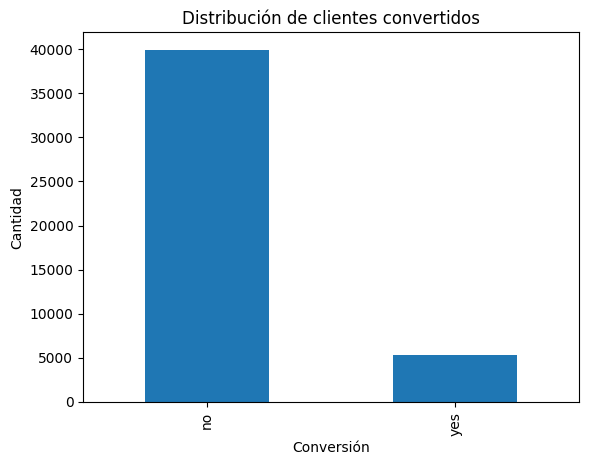

In [22]:
train['y'].value_counts().plot(kind='bar')

plt.title('Distribución de clientes convertidos')
plt.xlabel('Conversión')
plt.ylabel('Cantidad')
plt.show()

Paso 10: Separar variables predictoras y variable objetivo

In [23]:
X_train = train.drop('y', axis=1)
y_train = train['y']

X_test = test.drop('y', axis=1)
y_test = test['y']

Paso 11: Transformar variables categóricas

In [24]:
# Crear encoder
le = LabelEncoder()

# Transformar columnas categóricas
for col in X_train.columns:
    if X_train[col].dtype == 'object':

        # Ajustar encoder en train
        X_train[col] = le.fit_transform(X_train[col])

        # Aplicar transformación en test
        X_test[col] = le.transform(X_test[col])

# Transformar variable objetivo
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [25]:
X_train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,58,4,1,2,0,2143,1,0,2,5,8,261,1,-1,0,3
1,44,9,2,1,0,29,1,0,2,5,8,151,1,-1,0,3
2,33,2,1,1,0,2,1,1,2,5,8,76,1,-1,0,3
3,47,1,1,3,0,1506,1,0,2,5,8,92,1,-1,0,3
4,33,11,2,3,0,1,0,0,2,5,8,198,1,-1,0,3


Paso 12: Entrenar el modelo de Machine Learning.
🌳 Árbol de Decisión (Decision Tree)

In [26]:
# Crear modelo
modelo = DecisionTreeClassifier(random_state=42)

# Entrenar modelo
modelo.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Paso 13: Realizar predicciones

In [27]:
# Generar predicciones
y_pred = modelo.predict(X_test)

Paso 14: Crear la matriz de confusión

In [28]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

cm

array([[4000,    0],
       [   0,  521]])

Paso 15: Visualizar la matriz de confusión

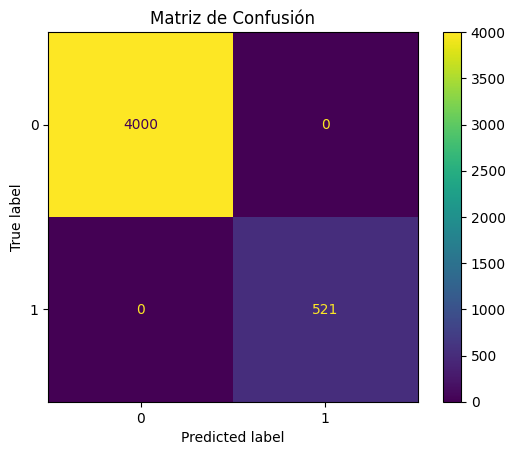

In [29]:
# Mostrar matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title('Matriz de Confusión')
plt.show()

Paso 16: Calcular el Accuracy del modelo

In [30]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy del modelo:", accuracy)

Accuracy del modelo: 1.0


Paso 17: Obtener métricas completas

In [31]:
# Reporte de clasificación
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4000
           1       1.00      1.00      1.00       521

    accuracy                           1.00      4521
   macro avg       1.00      1.00      1.00      4521
weighted avg       1.00      1.00      1.00      4521



Paso 18: Eliminar la variable duration

In [33]:
# Eliminar variable duration
X_train2 = X_train.drop('duration', axis=1)
X_test2 = X_test.drop('duration', axis=1)

Paso 19: Entrenar nuevamente el modelo SIN duration

In [34]:
# Crear nuevo modelo
modelo2 = DecisionTreeClassifier(random_state=42)

# Entrenar modelo sin duration
modelo2.fit(X_train2, y_train)

DecisionTreeClassifier(random_state=42)

Paso 20: Generar nuevas predicciones

In [35]:
# Predicciones del nuevo modelo
y_pred2 = modelo2.predict(X_test2)

Paso 21: Calcular nueva matriz de confusión y accuracy

In [36]:
# Nueva matriz de confusión
cm2 = confusion_matrix(y_test, y_pred2)

# Accuracy nuevo
accuracy2 = accuracy_score(y_test, y_pred2)

print("Nuevo Accuracy:", accuracy2)
print(cm2)

Nuevo Accuracy: 1.0
[[4000    0]
 [   0  521]]


Paso 22: Ver nueva matriz gráficamente

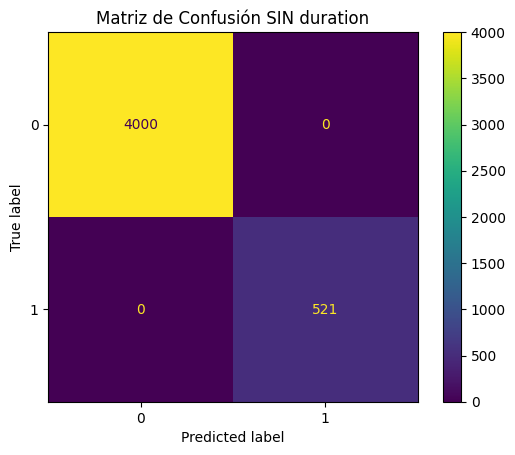

In [37]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm2)

disp.plot()

plt.title('Matriz de Confusión SIN duration')
plt.show()

Paso 23: Obtener nuevas métricas

In [38]:
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4000
           1       1.00      1.00      1.00       521

    accuracy                           1.00      4521
   macro avg       1.00      1.00      1.00      4521
weighted avg       1.00      1.00      1.00      4521



Paso 24: Importar métricas ROC

In [39]:
# Probabilidades de pertenecer a la clase positiva
y_prob = modelo2.predict_proba(X_test2)[:,1]

Paso 26: Calcular curva ROC y AUC

In [41]:
from sklearn.metrics import roc_curve, roc_auc_score

In [42]:
# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calcular AUC
auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)

AUC: 1.0


Paso 27: Graficar la Curva ROC

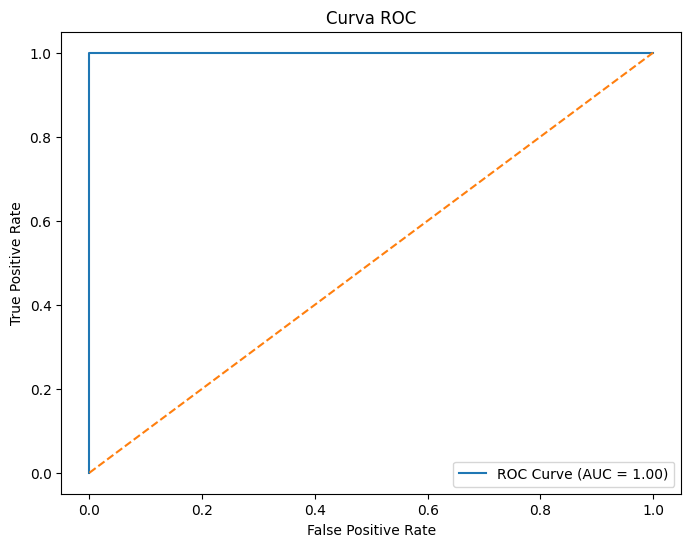

In [43]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label='ROC Curve (AUC = %0.2f)' % auc)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Curva ROC')

plt.legend()

plt.show()